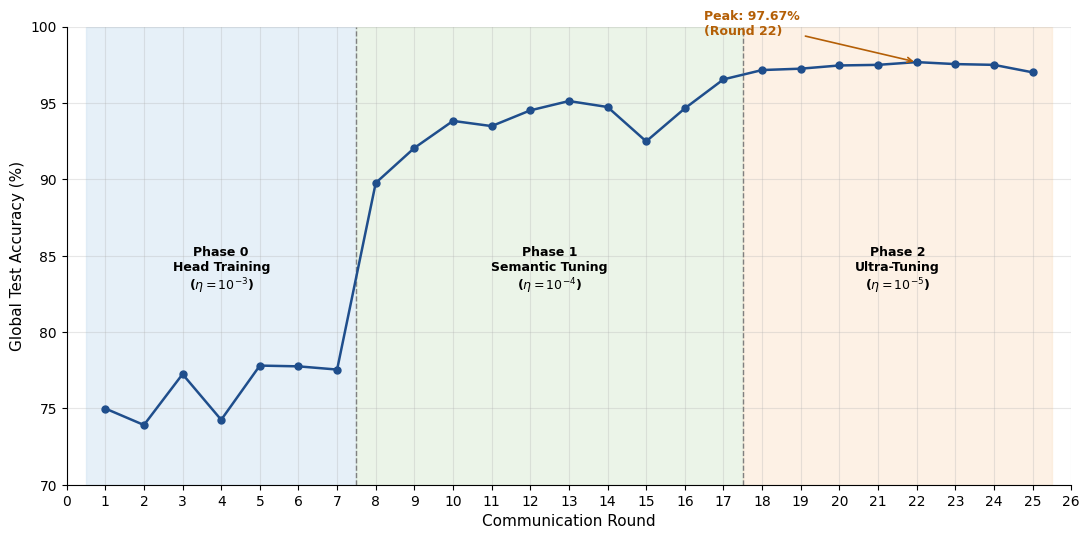

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Round-by-round global test accuracy (parsed from the training log) ----
rounds = list(range(1, 26))
accuracy = [
    74.99, 73.91, 77.24, 74.25, 77.80, 77.75, 77.54,   # Phase 0: Head Training (rounds 1-7)
    89.76, 92.05, 93.82, 93.48, 94.51, 95.12, 94.73,   # Phase 1: Semantic Tuning (rounds 8-17)
    92.48, 94.64, 96.54,
    97.15, 97.24, 97.45, 97.49, 97.67, 97.54, 97.49, 97  # Phase 2: Ultra-Tuning (rounds 18-25)
]

# ---- Phase boundaries (end round of each phase) ----
PHASE0_END = 7    # Head Training:      rounds 1-7
PHASE1_END = 17   # Semantic Tuning:    rounds 8-17
PHASE2_END = 25   # Ultra-Tuning:       rounds 18-25

# ---- Peak accuracy (found automatically from the data) ----
peak_round = rounds[int(np.argmax(accuracy))]
peak_acc = max(accuracy)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(11, 5.5))

# Phase shading
ax.axvspan(0.5, PHASE0_END + 0.5, color="#cfe2f3", alpha=0.5, zorder=0)
ax.axvspan(PHASE0_END + 0.5, PHASE1_END + 0.5, color="#d9ead3", alpha=0.5, zorder=0)
ax.axvspan(PHASE1_END + 0.5, PHASE2_END + 0.5, color="#fce5cd", alpha=0.5, zorder=0)

# Phase boundary dashed lines
ax.axvline(x=PHASE0_END + 0.5, color="gray", linestyle="--", linewidth=1)
ax.axvline(x=PHASE1_END + 0.5, color="gray", linestyle="--", linewidth=1)

# Accuracy line
ax.plot(rounds, accuracy, marker="o", markersize=5, color="#1f4e8c", linewidth=1.8, zorder=3)

# Peak annotation
ax.annotate(
    f"Peak: {peak_acc:.2f}%\n(Round {peak_round})",
    xy=(peak_round, peak_acc),
    xytext=(peak_round - 5.5, peak_acc + 1.8),
    fontsize=9, color="#b45f06", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#b45f06", lw=1.2),
)

# Phase labels
ax.text((1 + PHASE0_END) / 2, 84, "Phase 0\nHead Training\n" r"($\eta = 10^{-3}$)",
        ha="center", va="center", fontsize=9, fontweight="bold")
ax.text((PHASE0_END + 1 + PHASE1_END) / 2, 84, "Phase 1\nSemantic Tuning\n" r"($\eta = 10^{-4}$)",
        ha="center", va="center", fontsize=9, fontweight="bold")
ax.text((PHASE1_END + 1 + PHASE2_END) / 2, 84, "Phase 2\nUltra-Tuning\n" r"($\eta = 10^{-5}$)",
        ha="center", va="center", fontsize=9, fontweight="bold")

# Axes formatting
ax.set_xlabel("Communication Round", fontsize=11)
ax.set_ylabel("Global Test Accuracy (%)", fontsize=11)
ax.set_xlim(0, 26)
ax.set_ylim(70, 100)
ax.set_xticks(range(0, 27, 1))
ax.grid(axis="both", alpha=0.3)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("sfu_accuracy_plot.png", dpi=200)
plt.show()